In [4]:

# Install libraries
!pip install tensorflow numpy matplotlib -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import re

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print("All libraries imported successfully!")

TensorFlow version : 2.20.0
NumPy version      : 2.0.2
All libraries imported successfully!


In [5]:

# Load dataset
df = pd.read_csv("Shakespeare_data.csv")

# Show first 5 rows
print(df.head())

   Dataline      Play  PlayerLinenumber ActSceneLine         Player  \
0         1  Henry IV               NaN          NaN            NaN   
1         2  Henry IV               NaN          NaN            NaN   
2         3  Henry IV               NaN          NaN            NaN   
3         4  Henry IV               1.0        1.1.1  KING HENRY IV   
4         5  Henry IV               1.0        1.1.2  KING HENRY IV   

                                          PlayerLine  
0                                              ACT I  
1                       SCENE I. London. The palace.  
2  Enter KING HENRY, LORD JOHN OF LANCASTER, the ...  
3             So shaken as we are, so wan with care,  
4         Find we a time for frighted peace to pant,  


In [6]:
#Clean & Preprocess the Text

import re

# Extract only the dialogue column
lines = df['PlayerLine'].dropna().astype(str).tolist()

print(f"Total lines before cleaning : {len(lines):,}")

#Cleaning Function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Apply cleaning
cleaned_lines = [clean_text(line) for line in lines]

# Remove very short lines (less than 3 words)
cleaned_lines = [line for line in cleaned_lines if len(line.split()) >= 3]

print(f"Total lines after cleaning  : {len(cleaned_lines):,}")

# Preview Before vs After
print("\n📋 Before vs After Cleaning:")
print("=" * 55)

for i in range(3):
    print(f"Original : {lines[i]}")
    print(f"Cleaned  : {cleaned_lines[i]}")
    print()

print("Text cleaning complete!")

Total lines before cleaning : 111,396
Total lines after cleaning  : 105,183

📋 Before vs After Cleaning:
Original : ACT I
Cleaned  : scene i london the palace

Original : SCENE I. London. The palace.
Cleaned  : enter king henry lord john of lancaster the earl of westmoreland sir walter blunt and others

Original : Enter KING HENRY, LORD JOHN OF LANCASTER, the EARL of WESTMORELAND, SIR WALTER BLUNT, and others
Cleaned  : so shaken as we are so wan with care

Text cleaning complete!


In [11]:
#Tokenization

from tensorflow.keras.preprocessing.text import Tokenizer

# Create tokenizer and fit on text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(cleaned_lines)

# Vocabulary size
total_words = len(tokenizer.word_index) + 1

print("Total Vocabulary Size:", total_words)

# Show first 10 word mappings
print("\nWord → Index:")
for word, idx in list(tokenizer.word_index.items())[:10]:
    print(word, "→", idx)

# Show top 10 frequent words
print("\nTop 10 Frequent Words:")
word_counts = sorted(tokenizer.word_counts.items(), key=lambda x: x[1], reverse=True)[:10]
for word, count in word_counts:
    print(word, "→", count)

# Convert one sentence to tokens
sample = cleaned_lines[0]
tokens = tokenizer.texts_to_sequences([sample])[0]

print("\nSample Sentence:", sample)
print("Tokenized:", tokens)

print("\n Tokenization Done")

Total Vocabulary Size: 27202

Word → Index:
the → 1
and → 2
i → 3
to → 4
of → 5
a → 6
you → 7
my → 8
in → 9
that → 10

Top 10 Frequent Words:
the → 26966
and → 24998
i → 19987
to → 18258
of → 15835
a → 13992
you → 13268
my → 11790
in → 10481
that → 10375

Sample Sentence: scene i london the palace
Tokenized: [129, 3, 799, 1, 559]

 Tokenization Done


In [12]:
#Generate N-Gram Sequences (Simple Version)


input_sequences = []

# Generate sequences
for line in cleaned_lines:
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

print("Total Sequences Generated:", len(input_sequences))

# Show sample sequences
print("\nSample Sequences:")
for seq in input_sequences[:5]:
    print(seq)

# Example explanation
sample_line = cleaned_lines[0]
sample_tokens = tokenizer.texts_to_sequences([sample_line])[0]

print("\nSample Line:", sample_line)
print("Token List:", sample_tokens)

print("\nGenerated Sequences from Sample:")
for i in range(1, len(sample_tokens)):
    print(sample_tokens[:i+1])

print("\n Sequence Generation Done")

Total Sequences Generated: 699664

Sample Sequences:
[129, 3]
[129, 3, 799]
[129, 3, 799, 1]
[129, 3, 799, 1, 559]
[83, 88]

Sample Line: scene i london the palace
Token List: [129, 3, 799, 1, 559]

Generated Sequences from Sample:
[129, 3]
[129, 3, 799]
[129, 3, 799, 1]
[129, 3, 799, 1, 559]

 Sequence Generation Done


In [13]:

#Padding & Create X, y (Simple Version)

# Find maximum sequence length
max_seq_len = max(len(seq) for seq in input_sequences)
print("Max Sequence Length:", max_seq_len)

# Pad sequences
padded_sequences = pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre')
padded_sequences = np.array(padded_sequences)

print("Padded Shape:", padded_sequences.shape)

# Split into input (X) and output (y)
X = padded_sequences[:, :-1]
y = padded_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

# Show example
print("\nExample:")
for i in range(3):
    print("Input (X):", X[i], "→ Output (y):", y[i])

print("\n Padding & Data Preparation Done")

Max Sequence Length: 163
Padded Shape: (699664, 163)
X shape: (699664, 162)
y shape: (699664,)

Example:
Input (X): [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 129] → Output (y): 3
Input (X): [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0 

In [16]:

#Build LSTM Model
model = Sequential(name="LSTM_Shakespeare_Predictor")

#Layer 1: Embedding

model.add(Embedding(
    input_dim  = total_words,
    output_dim = 100
))

#Layer 2: First LSTM
model.add(LSTM(
    150,
    return_sequences=True
))

# Layer 3: Second LSTM

model.add(LSTM(100))

#Layer 4: Dropout
model.add(Dropout(0.3))

# Layer 5: Dense Output

model.add(Dense(
    total_words,
    activation='softmax'
))

#Compile Model
model.compile(
    loss      = 'sparse_categorical_crossentropy',
    optimizer = 'adam',
    metrics   = ['accuracy']
)

#Print Summary
print("=" * 50)
print("MODEL ARCHITECTURE SUMMARY")
print("=" * 50)
model.summary()

#Layer Explanation
print("\n Layer Explanation:")
print("-" * 50)
print("  Layer 1 - Embedding  : Word index → 100D vector")
print("  Layer 2 - LSTM(150)  : Learns basic patterns")
print("  Layer 3 - LSTM(100)  : Learns complex patterns")
print("  Layer 4 - Dropout    : Prevents overfitting")
print("  Layer 5 - Dense      : Predicts next word")
print("\n Model built successfully!")

MODEL ARCHITECTURE SUMMARY


Model: "LSTM_Shakespeare_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


 Layer Explanation:
--------------------------------------------------
  Layer 1 - Embedding  : Word index → 100D vector
  Layer 2 - LSTM(150)  : Learns basic patterns
  Layer 3 - LSTM(100)  : Learns complex patterns
  Layer 4 - Dropout    : Prevents overfitting
  Layer 5 - Dense      : Predicts next word

 Model built successfully!


In [18]:
#Train the Model

X = X[:25000]
y = y[:25000]

history = model.fit(
    X, y,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/20
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0902 - loss: 6.2781
Epoch 1: val_loss improved from None to 6.53464, saving model to model/lstm_best.keras

Epoch 1: finished saving model to model/lstm_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.0911 - loss: 6.2748 - val_accuracy: 0.0896 - val_loss: 6.5346
Epoch 2/20
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0947 - loss: 6.0678
Epoch 2: val_loss did not improve from 6.53464
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.0947 - loss: 6.0736 - val_accuracy: 0.0840 - val_loss: 6.5533
Epoch 3/20
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0975 - loss: 5.9196
Epoch 3: val_loss did not improve from 6.53464
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.1001 - loss: 5.9296 - val_accuracy: 0.0816 - val_loss: 6.5921
Epoch 4/20
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1054 - loss: 5.8126
Epoch 4: val_loss did not improve from 6.53464
176/176 ━━━━━

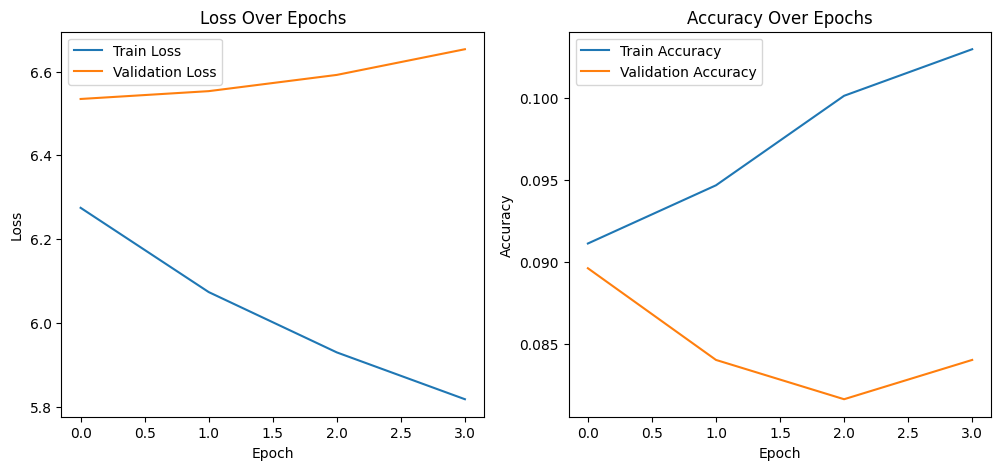

In [19]:
 #Plot Training Curves


# Plot Loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [22]:
 #Predict Next Word


# Create reverse mapping (index → word) for fast lookup
index_word = {v: k for k, v in tokenizer.word_index.items()}

def predict_next_word(seed_text):
    # Step 1 — Clean input
    seed_text = seed_text.lower()
    seed_text = re.sub(r"[^a-z\s]", "", seed_text)

    # Step 2 — Convert to tokens
    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    # Step 3 — Pad sequence
    token_list = pad_sequences(
        [token_list],
        maxlen=max_seq_len - 1,
        padding='pre'
    )

    # Step 4 — Predict next word
    predicted_probs = model.predict(token_list, verbose=0)
    predicted_index = np.argmax(predicted_probs)

    # Step 5 — Convert index to word
    return index_word.get(predicted_index, "[unknown]")

#Test Predictions
test_inputs = [
    "to be or not",
    "all the world",
    "the love of",
    "shall i compare",
    "what light through",
    "good night good"
]

print("=" * 55)
print(f"{'INPUT TEXT':<30} →  PREDICTED WORD")
print("=" * 55)

for text in test_inputs:
    print(f"{text:<30} →  {predict_next_word(text)}")

print("=" * 55)
print("\n Completed: Next Word Prediction Working!")

INPUT TEXT                     →  PREDICTED WORD
to be or not                   →  i
all the world                  →  of
the love of                    →  the
shall i compare                →  the
what light through             →  the
good night good                →  lord

 Completed: Next Word Prediction Working!


In [25]:
#Generate Multiple Words


def generate_text(seed_text, next_words, model, tokenizer, max_seq_len):
    """
    Generates multiple next words to continue a sentence.

    Args:
        seed_text  (str) : Starting phrase
        next_words (int) : How many words to generate
        model            : Trained LSTM model
        tokenizer        : Fitted Keras tokenizer
        max_seq_len(int) : Max sequence length used in training

    Returns:
        str: Extended text with generated words
    """
    result = seed_text

    for _ in range(next_words):
        # Predict next word and add to result
        next_word = predict_next_word(result)
        result = result + " " + next_word

    return result


#Test 1: Generate 5 Words
print("=" * 60)
print("TEST 1 — Generate 5 Words")
print("=" * 60)

seeds_5 = [
    "to be or not",
    "all the world is",
    "shall i compare thee",
    "friends romans countrymen lend",
    "now is the winter of"
]

for seed in seeds_5:
    generated = generate_text(seed, 5, model, tokenizer, max_seq_len)
    print(f"\n  Seed    : '{seed}'")
    print(f"  Output  : '{generated}'")


#Test 2: Generate 10 Words
print("\n" + "=" * 60)
print("TEST 2 — Generate 10 Words")
print("=" * 60)

seeds_10 = [
    "to be or not to be",
    "once more unto the breach",
    "all that glitters is not"
]

for seed in seeds_10:
    generated = generate_text(seed, 10, model, tokenizer, max_seq_len)
    print(f"\n  Seed    : '{seed}'")
    print(f"  Output  : '{generated}'")


#Test 3: Generate 15 Words
print("\n" + "=" * 60)
print("TEST 3 — Generate 15 Words")
print("=" * 60)

seeds_15 = [
    "what light through yonder window",
    "the quality of mercy is not"
]

for seed in seeds_15:
    generated = generate_text(seed, 15, model, tokenizer, max_seq_len)
    print(f"\n  Seed    : '{seed}'")
    print(f"  Output  : '{generated}'")


print("\n" + "=" * 60)
print(" Multi-word text generation working successfully!")
print("=" * 60)

TEST 1 — Generate 5 Words

  Seed    : 'to be or not'
  Output  : 'to be or not i have not i have'

  Seed    : 'all the world is'
  Output  : 'all the world is the king of the king'

  Seed    : 'shall i compare thee'
  Output  : 'shall i compare thee and the king of the'

  Seed    : 'friends romans countrymen lend'
  Output  : 'friends romans countrymen lend me i have not i'

  Seed    : 'now is the winter of'
  Output  : 'now is the winter of the king of the king'

TEST 2 — Generate 10 Words

  Seed    : 'to be or not to be'
  Output  : 'to be or not to be the king of the king of the king of the'

  Seed    : 'once more unto the breach'
  Output  : 'once more unto the breach of the king of the king of the king of'

  Seed    : 'all that glitters is not'
  Output  : 'all that glitters is not i have not i have not i have not i'

TEST 3 — Generate 15 Words

  Seed    : 'what light through yonder window'
  Output  : 'what light through yonder window and the king of the king of the king